Part A

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
x = np.sort(2*np.pi*np.random.rand(20))
noise_amp = 0.5
rng = np.random.default_rng(42) 
noise = rng.uniform(-noise_amp, noise_amp, size=x.shape)
y = np.cos(x) + noise                  


In [3]:
A = np.vstack([x, np.ones(len(x))]).T
# Solve using least squares
m, c = np.linalg.lstsq(A, y, rcond=None)[0]

In [4]:
# Step 2: Polynomial fitting using NumPy's polyfit
# Fit a 2nd degree polynomial to the data
degree = 3 # Degree of the polynomial
coefficients = np.polyfit(x, y, degree)
print("Polynomial Coefficients: ", coefficients)

polynomial = np.poly1d(coefficients)

Polynomial Coefficients:  [ 0.01137197  0.12364624 -1.18476391  1.47679416]


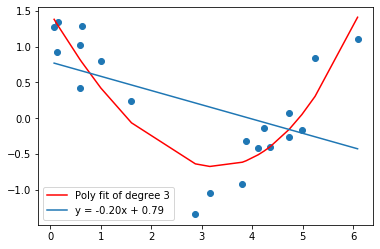

In [5]:
    y_pred = polynomial(x)
    plt.scatter(x, y)
    
    x_line = np.linspace(min(x), max(x), 20)
    plt.plot(x, y_pred, color='red', label=f'Poly fit of degree {degree}')
    
    y_line = m * x_line + c
    plt.plot(x_line, y_line ,label=f'y = {m:.2f}x + {c:.2f}')

    plt.legend()
    plt.show()

In [6]:
mse_linear = np.mean((y - y_line)**2)
ss_total = np.sum((y - np.mean(y))**2)
ss_res_linear = np.sum((y - y_line)**2)
r2_linear = 1 - (ss_res_linear / ss_total)

mse_poly = np.mean((y - y_pred)**2)
ss_res_poly = np.sum((y - y_pred)**2)
r2_poly = 1 - (ss_res_poly / ss_total)

print("Linear Fit:")
print(f"MSE = {mse_linear:.4f}, R^2 = {r2_linear:.4f}")

print("\nPolynomial Fit:")
print(f"MSE = {mse_poly:.4f}, R^2 = {r2_poly:.4f}")

print("\nModel Comparison:")

if mse_poly < mse_linear:
    print("Polynomial fit is better.")
elif mse_linear < mse_poly:
    print("Linear least squares fit is better.")
else:
    print("Cannot determine: both models have the same MSE.")

Linear Fit:
MSE = 0.5741, R^2 = 0.1265

Polynomial Fit:
MSE = 0.1124, R^2 = 0.8290

Model Comparison:
Polynomial fit is better.


Part B:

Degree | MSE | R^2 | Fit Type
--------------------------------
     1 | 0.5021 | 0.2360 | under fit
     2 | 0.1151 | 0.8249 | good fit
     3 | 0.1124 | 0.8290 | good fit
     4 | 0.0735 | 0.8882 | good fit
     5 | 0.0728 | 0.8892 | overfit
     6 | 0.0670 | 0.8980 | good fit
     7 | 0.0501 | 0.9238 | good fit
     8 | 0.0443 | 0.9327 | good fit
     9 | 0.0430 | 0.9346 | good fit
    10 | 0.0416 | 0.9367 | good fit


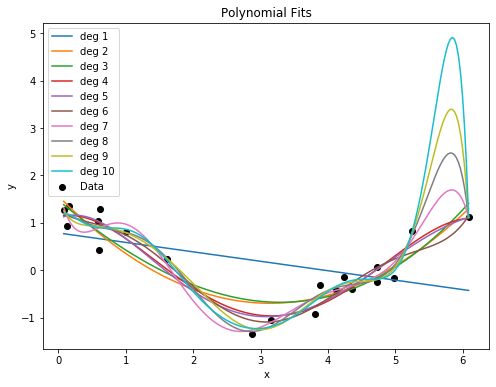

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(x, y, color='black', label='Data')

x_line = np.linspace(min(x), max(x), 200)

previous_mse = None

print("Degree | MSE | R^2 | Fit Type")
print("--------------------------------")

for degree in range(1, 11):

    coeffs = np.polyfit(x, y, degree)
    polynomial = np.poly1d(coeffs)

    y_pred = polynomial(x)

   
    mse = np.mean(( y - y_pred )**2)

    ss_total = np.sum(( y - np.mean(y) )**2)
    ss_res = np.sum((y - y_pred)**2)
    r2 = 1 - ss_res/ss_total

   
    fit_type = "good fit"

    if r2 < 0.4:
        fit_type = "under fit"

    if previous_mse is not None:
        improvement = previous_mse - mse

        if improvement < 0.001:
            fit_type = "overfit"

    previous_mse = mse

    print(f"{degree:6} | {mse:6.4f} | {r2:6.4f} | {fit_type}")

    y_line = polynomial(x_line)
    plt.plot(x_line, y_line, label=f"deg {degree}")

plt.legend()
plt.title("Polynomial Fits")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Challenge C:

In [8]:

degree = 2
V = np.vander(x, N=degree+1, increasing=True)


coeffs, _, _, _ = np.linalg.lstsq(V, y, rcond=None)


y_pred = V @ coeffs


mse = np.mean((y - y_pred)**2)


ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_pred)**2)
r2 = 1 - (ss_res / ss_total)

print("\nPolynomial Fit using Vandermonde Matrix:")
print("Coefficients:", coeffs)
print(f"MSE = {mse:.4f}")
print(f"R^2 = {r2:.4f}")


Polynomial Fit using Vandermonde Matrix:
Coefficients: [ 1.56657813 -1.44205507  0.22954451]
MSE = 0.1151
R^2 = 0.8249
